In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report
from sklearn.naive_bayes import MultinomialNB


In [ ]:
df = pd.read_csv('/content/spam.csv', encoding = 'latin-1')[['v1', 'v2']]
df.columns = ['label', 'text']

In [ ]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

In [ ]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['text'])
Y = df['label']

In [11]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size= 0.2, random_state= 42)

In [12]:
model = MultinomialNB()
model.fit(X_train, Y_train)

MultinomialNB()

In [15]:
y_pred = model.predict(X_test)

In [19]:
print("Accuracy:", accuracy_score(Y_test, y_pred))
print("Precision:", precision_score(Y_test, y_pred))
print("Recall:", recall_score(Y_test, y_pred))
print("F1 Score:", f1_score(Y_test, y_pred))
print("\nClassification Report:\n", classification_report(Y_test, y_pred))


Accuracy: 0.97847533632287
Precision: 0.9144736842105263
Recall: 0.9266666666666666
F1 Score: 0.9205298013245033

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       965
           1       0.91      0.93      0.92       150

    accuracy                           0.98      1115
   macro avg       0.95      0.96      0.95      1115
weighted avg       0.98      0.98      0.98      1115



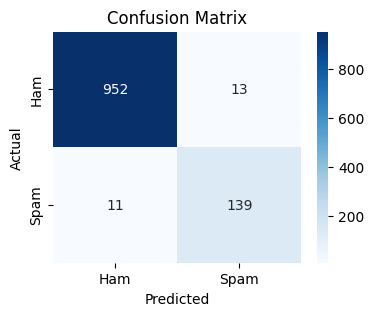

In [20]:
cm = confusion_matrix(Y_test, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

/tmp/ipython-input-23-1267792892.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=word_freq.values, y=word_freq.index, palette='mako')


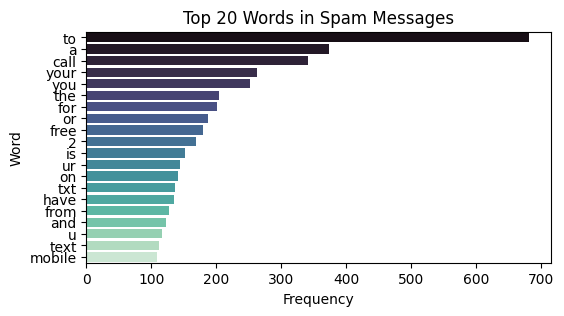

In [23]:
spam_words = df[df['label'] == 1]['text']
all_words = ' '.join(spam_words).lower().split()
word_freq = pd.Series(all_words).value_counts().head(20)

plt.figure(figsize=(6,3))
sns.barplot(x=word_freq.values, y=word_freq.index, palette='mako')
plt.title("Top 20 Words in Spam Messages")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()